In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 788953) PSD_funcs: (3, 394476)
[TRUE] SNR: 95.307243
[TRUE] SNR - Channel 0: 47.962480
[TRUE] SNR - Channel 1: 82.359363
[TRUE] SNR - Channel 2: 0.079973
[INFO] Frequency resolution delta_f: 1.267503e-07 Hz, Number of frequency bins: 394477
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


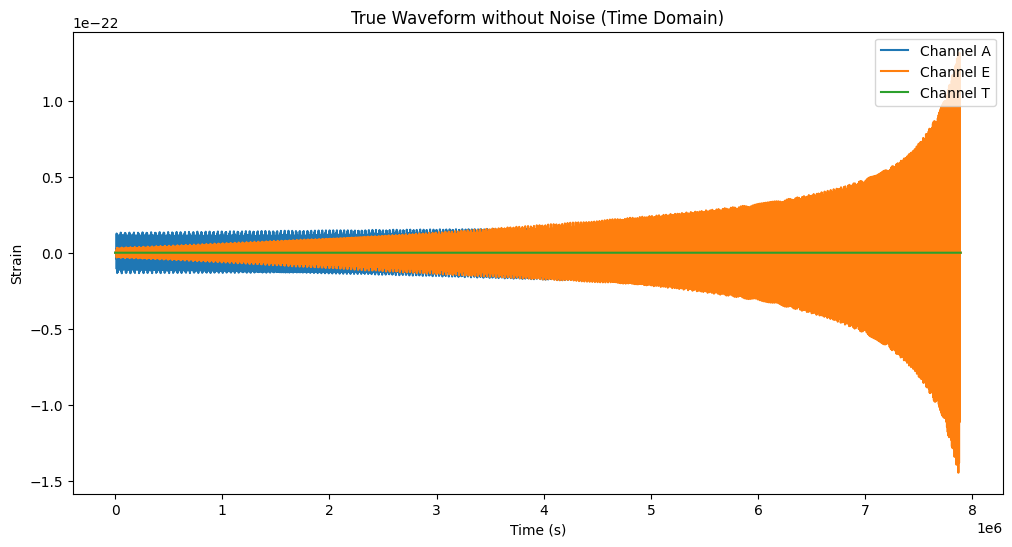

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 394476)


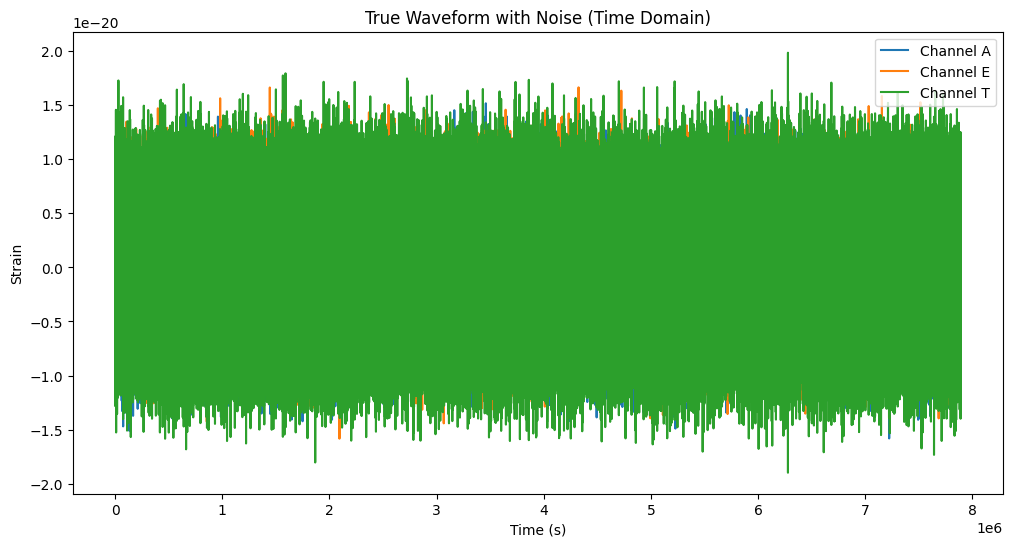

Length of PSD: 394476


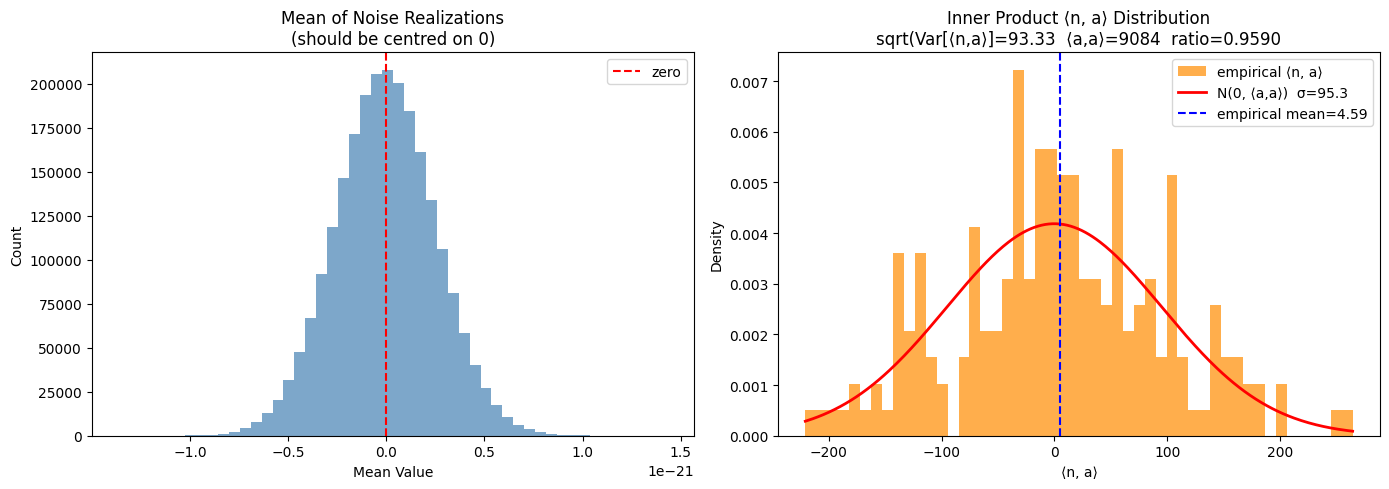

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 788950  |  PSD bins passed: 394475
  N (template samples)   : 788953  →  aligned to 788950
  Max |mean noise|       : 1.4279e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 4.5909e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 8710.77
  ⟨a, a⟩                : 9083.64
  Ratio Var/⟨a,a⟩       : 0.958952          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[ 2.48360296e-22, -1.35048831e-22,  1.07962550e-22, ...,
         3.82699322e-22, -2.40724836e-22,  5.42400267e-23],
       [-2.47328944e-22,  2.22439633e-22, -6.31564758e-24, ...,
        -4.54754517e-22,  7.98487013e-23, -1.09507270e-22],
       [ 2.62495603e-22, -2.53760104e-22,  2.61489531e-22, ...,
        -1.14390643e-22,  8.89550111e-23, -9.29492933e-23]],
      shape=(3, 788950)), 'inner_products': array([  21.2413129 ,  -75.95018625,   99.36699227,   -5.69198828,
         5

{'m1': np.float64(1000000.0),
 'm2': np.float64(5000.0),
 'a': np.float64(0.7),
 'p0': np.float64(25.0),
 'e0': np.float64(0.25),
 'Y0': np.float64(1.0),
 'dist': np.float64(12.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 0.25,
 'chi2': 0.95,
 'dev_1': 1.0,
 'dev_2': 1.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552bc6e6900>,
 'PSD_funcs': array([[4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.25581070e-55, 1.70232428e-54, 3.83022963e-54, ...,
         5.36087803e-40, 5.36079136e-40, 5.36070468e-40]],
       shape=(3, 394476)),
 'waveform_true_fft': array([[-7.82112057e-16

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,5e3,0.70, 25.0,  0.25,  1.00000000e+00,3, 
                    np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01,   5.00000000e-01,  4.00000000e-01])

signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 12,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 0.25

chi2 = 0.95 
dev_1 = 1.0
dev_2 = 1.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


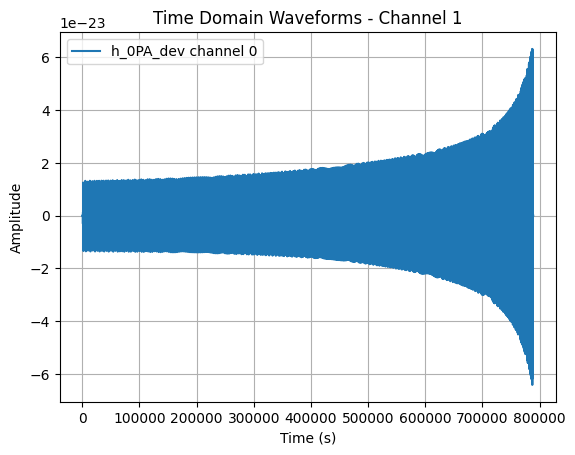

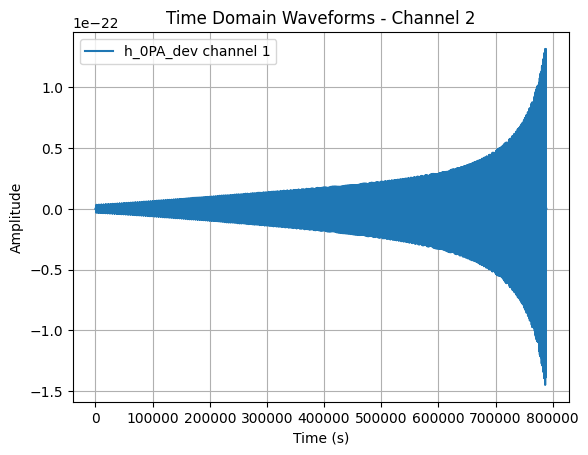

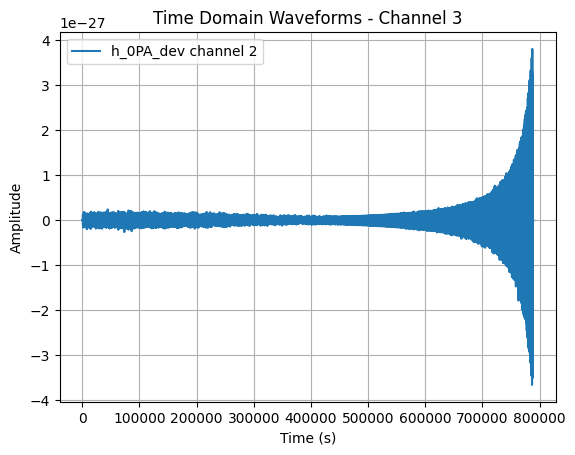

square of overlap in each channel 1: 48.09876183270873
square of overlap in each channel 2: 82.44348077507048
square of overlap in each channel 3: 0.0766358619352128
noise inner product with 0PA: 177.69753488428105
detection SNR 1.8588927590688187
Actual overlap: 95.4485426038784
detection SNR using true waveform: 95.30408931581208
detection SNR using actual signal: 97.1629820748809


In [4]:
x_best_fit_0PA_dev =  [1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847]
add_kwargs = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_0PA_dev_f[i], ctx['waveform_true_fft_without_noise'][i], ctx['PSD_funcs'][i], ctx['delta_f'], xp=xp)))
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

/tmp/ipykernel_866007/3879136084.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


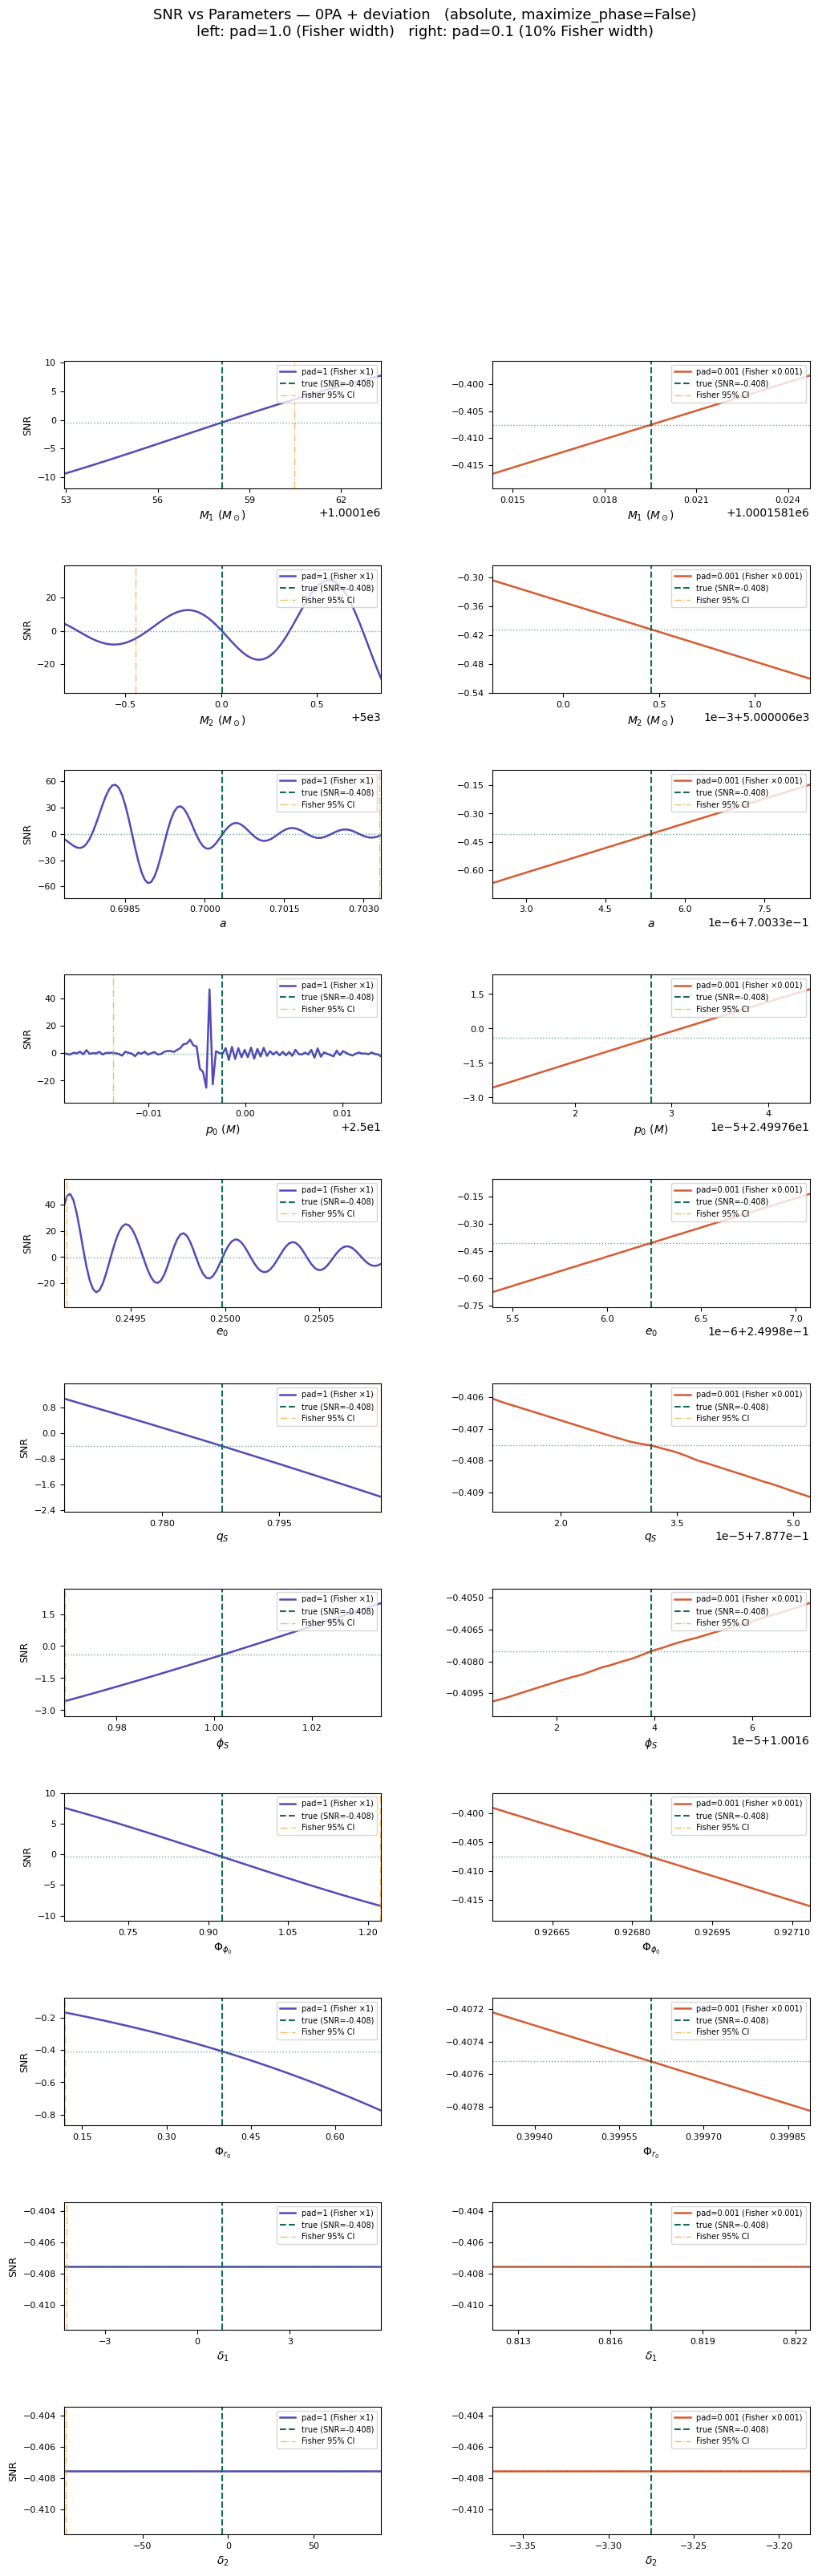

In [5]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev =  [1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847]
add_kwargs = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

bounds_0PA_dev = [(np.float64(1000150.084884085), np.float64(1000160.4627542491)),
                   (np.float64(4999.553400529875), np.float64(5001.2075202277765)),
                     (np.float64(0.697308952629192), np.float64(0.7032989976730175)),
                       (np.float64(24.986317185090143), np.float64(25.019154628132045)),
                         (np.float64(0.24915691122660052), np.float64(0.2508425962113327)),
                           (np.float64(0.7673162027141252), np.float64(0.8081551271945377)),
                             (np.float64(0.9694519707763845), np.float64(1.0343523601287874)), 
                             (np.float64(0.6277211897527446), np.float64(1.2235553814656208)),
                               (np.float64(0.11984248526932006), np.float64(0.6837857614174172)),
                                 (np.float64(-4.250676087905601), np.float64(6.056333790951486)),
                                   (np.float64(-95.1157256316985), np.float64(90.69693272269404))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
PAD_FACTORS = [1, 0.001]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    # Desired window around true value
    window   = pad * half  # half-width of the zoomed range
    raw_lo   = true_val - window
    raw_hi   = true_val + window

    # Clamp to physical bounds
    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    # Guard: if clamping collapsed the range, add a tiny epsilon
    if raw_hi - raw_lo < 1e-15:
        eps    = abs(true_val) * 1e-10 + 1e-30
        raw_lo = true_val - eps
        raw_hi = true_val + eps

    # Allocate points proportionally, guaranteeing true_val is a node
    total_range = raw_hi - raw_lo
    frac_left   = (true_val - raw_lo) / total_range  # always in (0, 1)
    n_left      = max(2, round(n_points * frac_left))
    n_right     = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        add_kwargs = {'chi2': 0.95, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2
    nrows = N_PARAMS            # 11 — grid exactly filled, no unused subplots

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            ax.set_xlim(grid[0], grid[-1])

            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.1 (10% Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [6]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="1st generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 10, Ndelta = 20,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, np.float64(1.0), np.float64(12.0), 0.787731667415743, 1.0016393337689735, np.float64(1.0), np.float64(1.0471975511965976), 0.926835171660422, np.float64(0.5), 0.399606527220177, 0.95, True, False, False, True, 0.8173148733981785, -3.275050808083847)
SNR:  95.5932148411271
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, np.float64(1.0), np.float64(12.0), 0.787731667415743, 1.0016393337689735, np.float64(1.0), np.float64(1.0471975511965976), 0.926835171660422, np.float64(0.5), 0.399606527220177, 0.95, True, False, False, True, 0.8173148733981785, -3.275050808083847)
Waveform Generated. SNR: 95.5932148411271
calculating stable deltas...
Gamma_ii for m1: 78

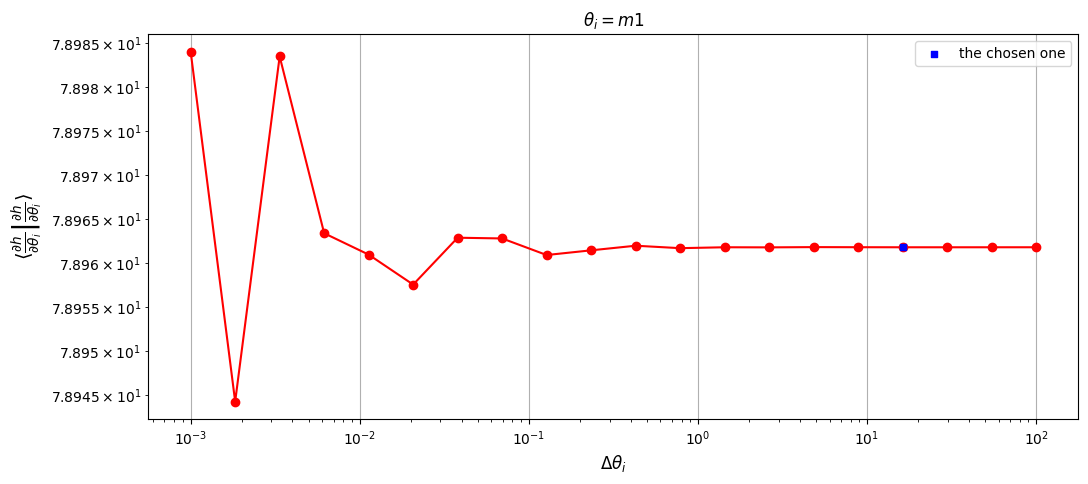

Gamma_ii for m2: 331140.90049749444
Gamma_ii for m2: 331140.8786479404
Gamma_ii for m2: 331140.9260838998
Gamma_ii for m2: 331141.0505389255
Gamma_ii for m2: 331141.291394506
Gamma_ii for m2: 331140.837814928
Gamma_ii for m2: 331140.39550906833
Gamma_ii for m2: 331141.914849787
Gamma_ii for m2: 331145.95431663166
Gamma_ii for m2: 331136.93770511023
Gamma_ii for m2: 331142.5320189349
Gamma_ii for m2: 331153.00044430257
Gamma_ii for m2: 331150.4795455365
Gamma_ii for m2: 331152.2437400726
Gamma_ii for m2: 331084.31172453886
Gamma_ii for m2: 331117.15387274453
Gamma_ii for m2: 331307.5615890617
Gamma_ii for m2: 331098.38473854144
Gamma_ii for m2: 330916.25874521816
Gamma_ii for m2: 331032.8268851413
[np.float64(6.598265403323144e-08), np.float64(1.432500656279664e-07), np.float64(3.7583689943630687e-07), np.float64(7.273498858222395e-07), np.float64(1.3697482346719886e-06), np.float64(1.335704932537756e-06), np.float64(4.588186063301935e-06), np.float64(1.219844842427516e-05), np.float64(

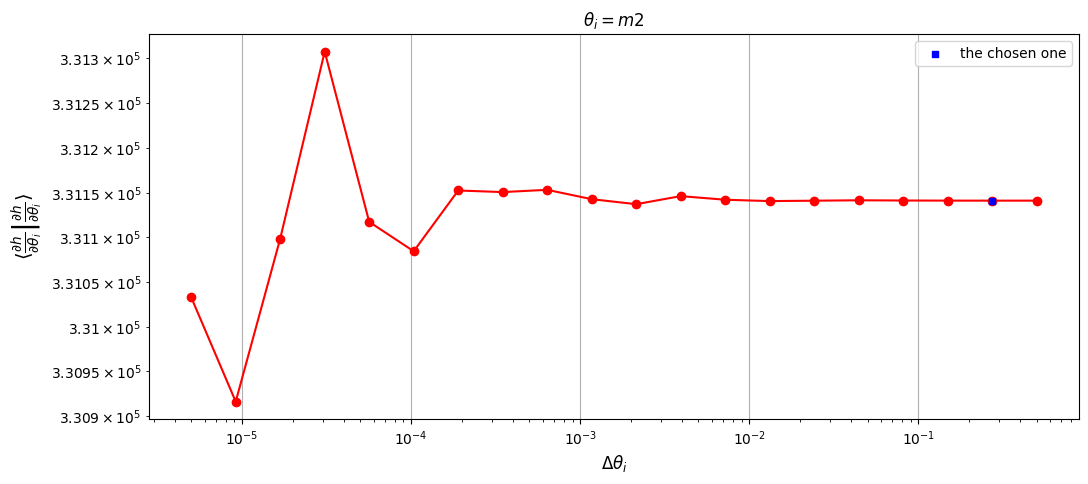

Gamma_ii for a: 172264348040.87967
Gamma_ii for a: 172264203776.1542
Gamma_ii for a: 172264001193.26797
Gamma_ii for a: 172265355666.00317
Gamma_ii for a: 172265035107.72122
Gamma_ii for a: 172263665667.81012
Gamma_ii for a: 172263098799.11835
Gamma_ii for a: 172260492724.98416
Gamma_ii for a: 172255926687.5611
Gamma_ii for a: 172271833968.6657
Gamma_ii for a: 172274041986.1847
Gamma_ii for a: 172256405764.20737
Gamma_ii for a: 172203092281.14197
Gamma_ii for a: 172315332945.41837
Gamma_ii for a: 172539398227.39227
Gamma_ii for a: 172807683576.42947
Gamma_ii for a: 172005021449.50873
Gamma_ii for a: 171031181589.41666
Gamma_ii for a: 170898032014.50702
Gamma_ii for a: 166671997709.53842
[np.float64(8.374620048825091e-07), np.float64(1.1760024429200686e-06), np.float64(7.86271116419424e-06), np.float64(1.8608435644032579e-06), np.float64(7.94967357622063e-06), np.float64(3.2907145855625476e-06), np.float64(1.5128681527379689e-05), np.float64(2.6507287794788586e-05), np.float64(9.2338258

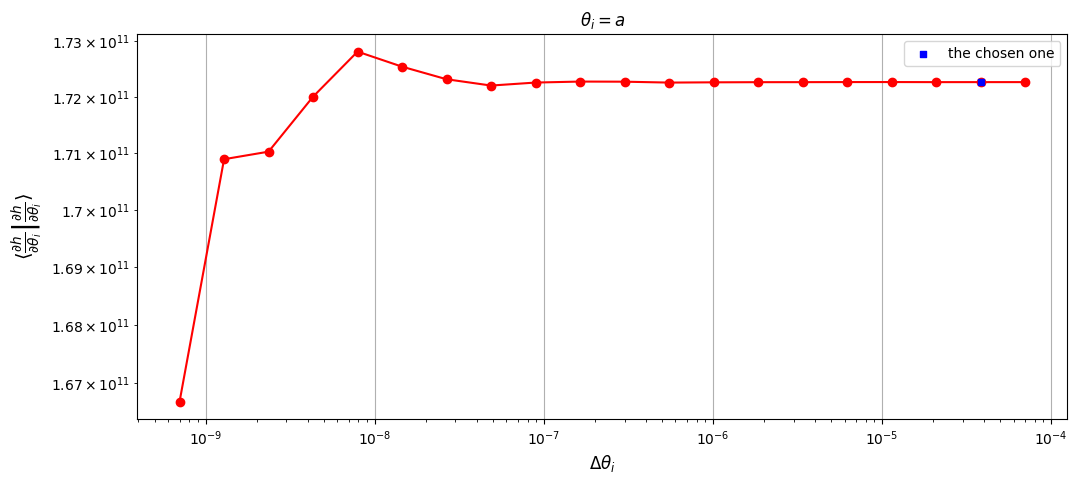

Gamma_ii for p0: 419765031331.6372
Gamma_ii for p0: 419765035942.7591
Gamma_ii for p0: 419765019100.2771
Gamma_ii for p0: 419765052242.6571
Gamma_ii for p0: 419765054146.6194
Gamma_ii for p0: 419764999450.2997
Gamma_ii for p0: 419764941269.8335
Gamma_ii for p0: 419765329887.6241
Gamma_ii for p0: 419765216797.20984
Gamma_ii for p0: 419765073384.8266
Gamma_ii for p0: 419765869421.11707
Gamma_ii for p0: 419764132712.33154
Gamma_ii for p0: 419766859840.94464
Gamma_ii for p0: 419767718891.651
Gamma_ii for p0: 419752744105.3668
Gamma_ii for p0: 419797240391.7339
Gamma_ii for p0: 419792089389.9718
Gamma_ii for p0: 419624179362.91223
Gamma_ii for p0: 419667661785.2854
Gamma_ii for p0: 419560960877.1243
[np.float64(1.0985007069135275e-08), np.float64(4.012359588878803e-08), np.float64(7.895459573829391e-08), np.float64(4.5357808170672636e-09), np.float64(1.3030224000041838e-07), np.float64(1.3860249026638897e-07), np.float64(9.257977324911904e-07), np.float64(2.694134952592794e-07), np.float64(

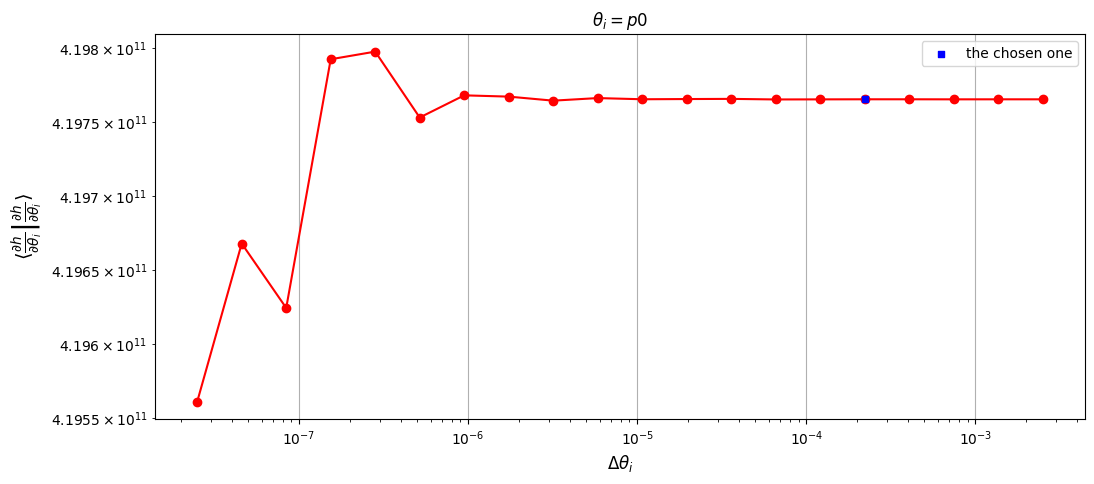

Gamma_ii for e0: 3558352908126.8213
Gamma_ii for e0: 3558354280727.1255
Gamma_ii for e0: 3558354612538.258
Gamma_ii for e0: 3558349799246.199
Gamma_ii for e0: 3558351509033.2236
Gamma_ii for e0: 3558328698878.5073
Gamma_ii for e0: 3558287699293.2075
Gamma_ii for e0: 3558313160276.0903
Gamma_ii for e0: 3558479421527.779
Gamma_ii for e0: 3558131803898.5254
Gamma_ii for e0: 3558476871512.0015
Gamma_ii for e0: 3558627416070.7393
Gamma_ii for e0: 3559006059120.274
Gamma_ii for e0: 3557328302495.59
Gamma_ii for e0: 3556434720109.0186
Gamma_ii for e0: 3556603346333.677
Gamma_ii for e0: 3551511019629.2573
Gamma_ii for e0: 3549524728058.6436
Gamma_ii for e0: 3559166371966.9824
Gamma_ii for e0: 3740984960857.3066
[np.float64(3.85740203451225e-07), np.float64(9.324847252576945e-08), np.float64(1.3526753495717026e-06), np.float64(4.804997539095283e-07), np.float64(6.410356278636586e-06), np.float64(1.1522279468281485e-05), np.float64(7.15535191423033e-06), np.float64(4.672255533715995e-05), np.flo

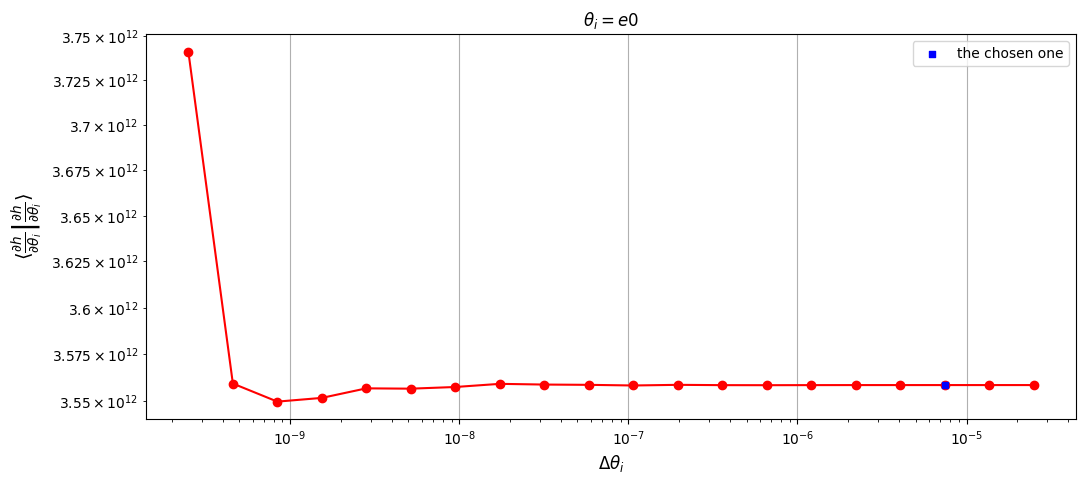

Gamma_ii for qS: 155117.9840057965
Gamma_ii for qS: 229319.42151426504
Gamma_ii for qS: 227860.9484507787
Gamma_ii for qS: 228901.09410091466
Gamma_ii for qS: 227526.04564240648
Gamma_ii for qS: 228049.45976318864
Gamma_ii for qS: 228020.8550066678
Gamma_ii for qS: 228384.87183763404
Gamma_ii for qS: 229648.44072729375
Gamma_ii for qS: 228170.58400441223
Gamma_ii for qS: 228092.281480556
Gamma_ii for qS: 228000.5882933737
Gamma_ii for qS: 228335.48871860077
Gamma_ii for qS: 232289.82922271988
Gamma_ii for qS: 234842.98407044428
Gamma_ii for qS: 262114.19562132182
Gamma_ii for qS: 669996.1452800399
Gamma_ii for qS: 1918804.9650806491
Gamma_ii for qS: 2402495.7519332245
Gamma_ii for qS: 2653017.2461918844
[np.float64(0.3235724083834425), np.float64(0.006400715319594962), np.float64(0.004544083348406364), np.float64(0.006043477152806035), np.float64(0.0022951780781488846), np.float64(0.00012544798378197366), np.float64(0.0015938745330952428), np.float64(0.005502187977667107), np.float64(0

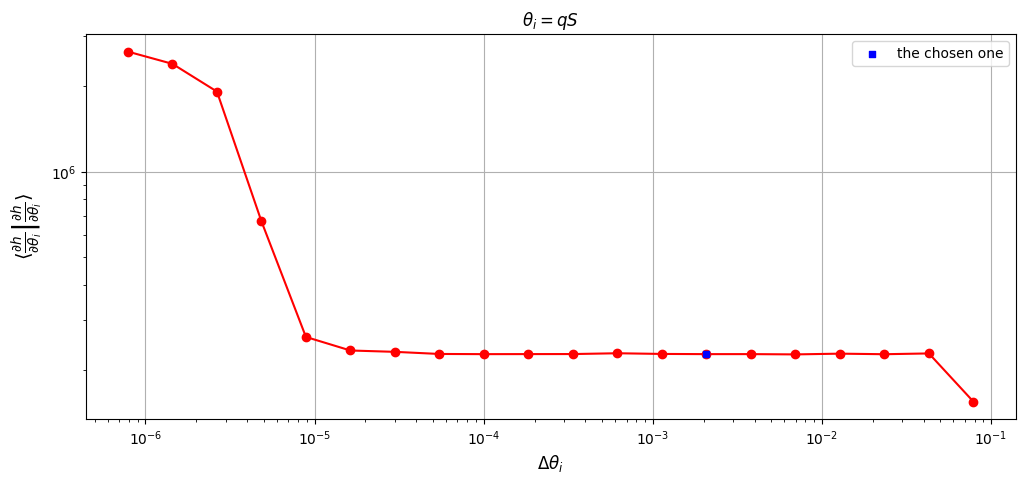

Gamma_ii for phiS: 320164.3791771766
Gamma_ii for phiS: 326137.16348810925
Gamma_ii for phiS: 326104.3131438526
Gamma_ii for phiS: 326157.15947989834
Gamma_ii for phiS: 326162.5641921398
Gamma_ii for phiS: 326178.7849404732
Gamma_ii for phiS: 326168.12365879
Gamma_ii for phiS: 326158.00555109984
Gamma_ii for phiS: 326171.3559673535
Gamma_ii for phiS: 326177.2064558682
Gamma_ii for phiS: 326166.17353384575
Gamma_ii for phiS: 326222.51792669354
Gamma_ii for phiS: 326329.00712041353
Gamma_ii for phiS: 327263.007103911
Gamma_ii for phiS: 328649.6401767894
Gamma_ii for phiS: 350736.5120855127
Gamma_ii for phiS: 543439.8526485189
Gamma_ii for phiS: 958161.0326806206
Gamma_ii for phiS: 994014.5109708838
Gamma_ii for phiS: 1520920.2867719885
[np.float64(0.018313718826313347), np.float64(0.0001007356938642558), np.float64(0.0001620272145184203), np.float64(1.6570608754014312e-05), np.float64(4.972962400480854e-05), np.float64(3.26864610912872e-05), np.float64(3.102210437266001e-05), np.float64(

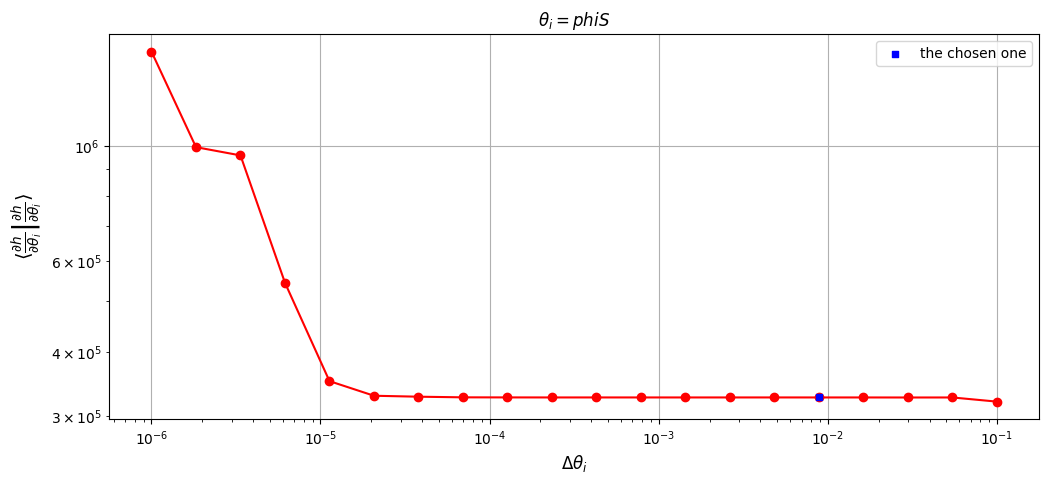

Gamma_ii for dev_1: 2763.926441363113
Gamma_ii for dev_1: 2763.924929811309
Gamma_ii for dev_1: 2763.9387018125203
Gamma_ii for dev_1: 2763.9615480239436
Gamma_ii for dev_1: 2763.87825165738
Gamma_ii for dev_1: 2763.903160837871
Gamma_ii for dev_1: 2764.20562692244
Gamma_ii for dev_1: 2763.987864214988
Gamma_ii for dev_1: 2764.207311768862
Gamma_ii for dev_1: 2763.163127996381
Gamma_ii for dev_1: 2763.7276694797524
Gamma_ii for dev_1: 2765.3390794812844
Gamma_ii for dev_1: 2761.4267337409797
Gamma_ii for dev_1: 2762.822910613142
Gamma_ii for dev_1: 2762.448997689104
Gamma_ii for dev_1: 2736.8392059173834
Gamma_ii for dev_1: 2782.530167455697
Gamma_ii for dev_1: 2861.28785667929
Gamma_ii for dev_1: 2948.9027182833956
Gamma_ii for dev_1: 3083.5906913022973
[np.float64(5.468859836645187e-07), np.float64(4.982744806245326e-06), np.float64(8.265748646029694e-06), np.float64(3.0137494845692248e-05), np.float64(9.012320273639277e-06), np.float64(0.0001094224256050586), np.float64(7.8785695940

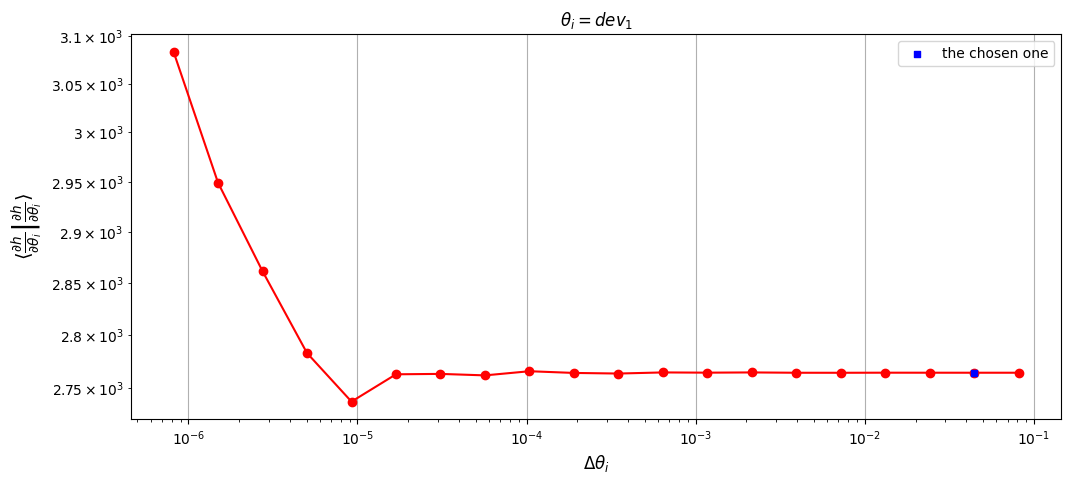

Gamma_ii for dev_2: 63.60932017901276
Gamma_ii for dev_2: 63.60950815891042
Gamma_ii for dev_2: 63.609137888418346
Gamma_ii for dev_2: 63.60880773362924
Gamma_ii for dev_2: 63.61015063996707
Gamma_ii for dev_2: 63.60634456090076
Gamma_ii for dev_2: 63.60854290873783
Gamma_ii for dev_2: 63.60236727061893
Gamma_ii for dev_2: 63.59142916876712
Gamma_ii for dev_2: 63.694216660708435
Gamma_ii for dev_2: 63.576854153423646
Gamma_ii for dev_2: 63.42485629063262
Gamma_ii for dev_2: 63.79120471156358
Gamma_ii for dev_2: 63.729404431479665
Gamma_ii for dev_2: 64.02339349047081
Gamma_ii for dev_2: 64.9855009229057
Gamma_ii for dev_2: 64.68213654599604
Gamma_ii for dev_2: 64.65160345065115
Gamma_ii for dev_2: 71.74569631525908
Gamma_ii for dev_2: 84.98665676066703
[np.float64(2.955216965216418e-06), np.float64(5.8210267324556485e-06), np.float64(5.190394237331276e-06), np.float64(2.1111510102000077e-05), np.float64(5.983804119829526e-05), np.float64(3.456057530239166e-05), np.float64(9.70976141914

/home/svu/e1583490/packages_to_install/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


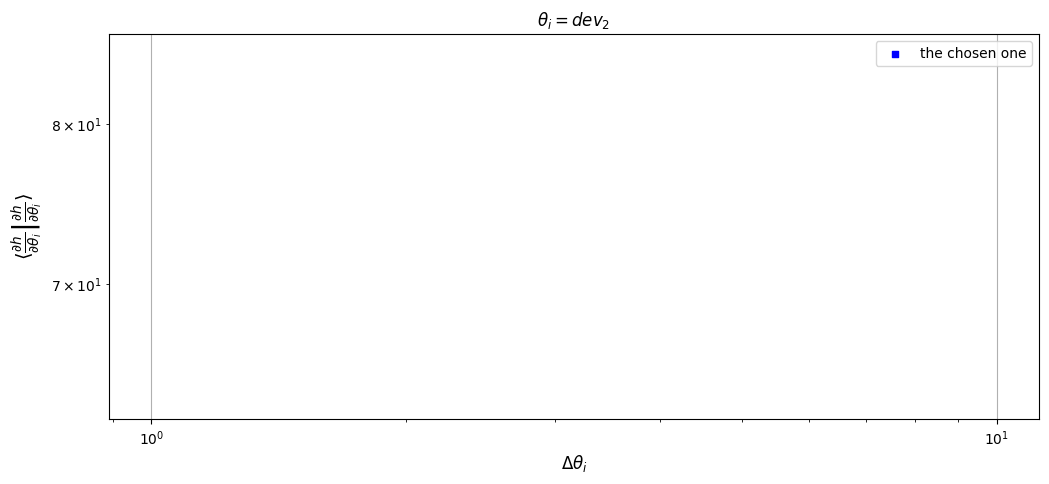

stable deltas: {'m1': 16.240334899866845, 'm2': 0.27278009137157216, 'a': 3.820745941799222e-05, 'p0': 0.00022144568385906166, 'e0': 7.44046885944888e-06, 'qS': 0.0020769734088500824, 'phiS': 0.008873190217544142, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.04458938757882512, 'dev_2': -0.17867350096643983}
Time taken to compute stable deltas is 61.84118318557739 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.023163318634033 seconds


In [7]:
x_best_fit_0PA_dev =  [1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847]
add_kwargs_0PA_dev = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)

# Covariance_fit_0PA_dev = fishinv(m1, Fisher, index_of_M=0)

In [ ]:
np.save('Fisher_1PA_dev_imri.npy', Fisher_0PA_dev)